# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [3]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [4]:
# Inspect the shapes of the datasets
print("=== Data shape analysis ===")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Minimum pixel value: {X_train.min()}, Maximum: {X_train.max()}")

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train_categorical = to_categorical(y_train, 10)
y_test_categorical = to_categorical(y_test, 10)

print(f"\nOne-hot encoded y_train shape: {y_train_categorical.shape}")

=== Data shape analysis ===
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Minimum pixel value: 0.0, Maximum: 1.0

One-hot encoded y_train shape: (60000, 10)



Class distribution in the training set:
T-shirt/top: 6000 images (10.0%)
Trouser: 6000 images (10.0%)
Pullover: 6000 images (10.0%)
Dress: 6000 images (10.0%)
Coat: 6000 images (10.0%)
Sandal: 6000 images (10.0%)
Shirt: 6000 images (10.0%)
Sneaker: 6000 images (10.0%)
Bag: 6000 images (10.0%)
Ankle boot: 6000 images (10.0%)


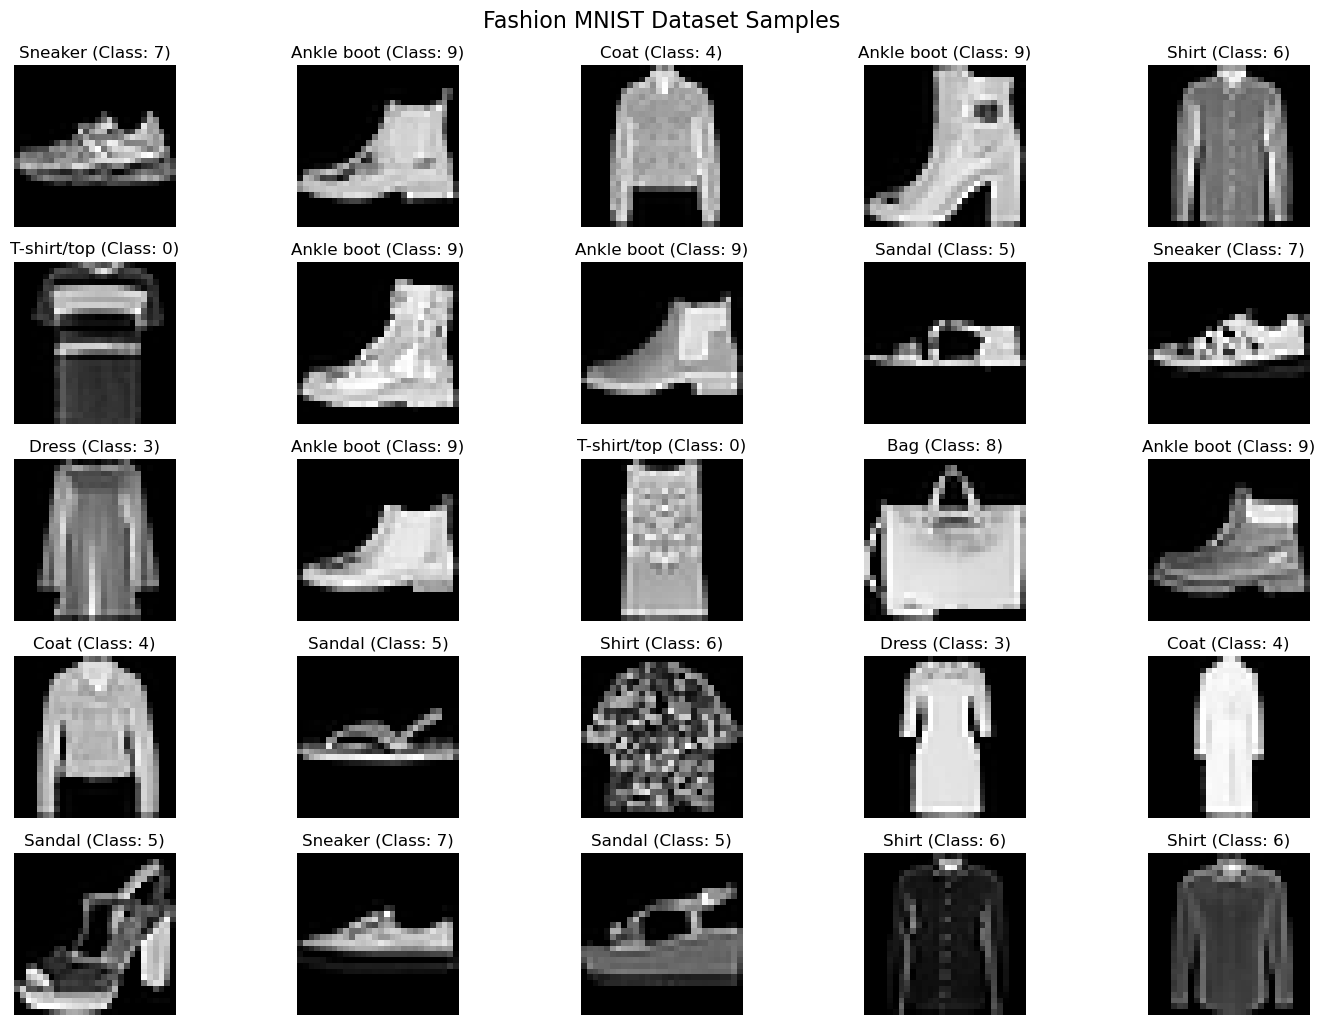


Image size: (28, 28)
Data type: float32


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Class distribution analysis
unique, counts = np.unique(y_train, return_counts=True)
print("\nClass distribution in the training set:")
for i, (cls, count) in enumerate(zip(unique, counts)):
    print(f"{class_names[cls]}: {count} images ({count/len(y_train)*100:.1f}%)")

# Verify the data looks as expected
plt.figure(figsize=(15, 10))

# Display 25 random images
indices = np.random.choice(len(X_train), 25, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"{class_names[y_train[idx]]} (Class: {y_train[idx]})")
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Fashion MNIST Dataset Samples', y=1.02, fontsize=16)
plt.show()

# Additional information about the images
print(f"\nImage size: {X_train[0].shape}")
print(f"Data type: {X_train[0].dtype}")


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

Flattened X_train shape: (60000, 784)
=== Baseline Model Architecture ===


c:\Users\vshch\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5645 - loss: 0.0983 - val_accuracy: 0.7697 - val_loss: 0.0494
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7812 - loss: 0.0473 - val_accuracy: 0.7951 - val_loss: 0.0431
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8046 - loss: 0.0419 - val_accuracy: 0.8007 - val_loss: 0.0408
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8142 - loss: 0.0396 - val_accuracy: 0.8130 - val_loss: 0.0389
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8126 - loss: 0.0392 - val_accuracy: 0.8162 - val_loss: 0.0384
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8159 - loss: 0.0383 - val_accuracy: 0.8148 - val_loss: 0.0385
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8211 - loss: 0.0374 - val_accuracy: 0.8117 - val_loss: 0.0386
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8179 - loss: 0.0374 - val_accuracy: 0.

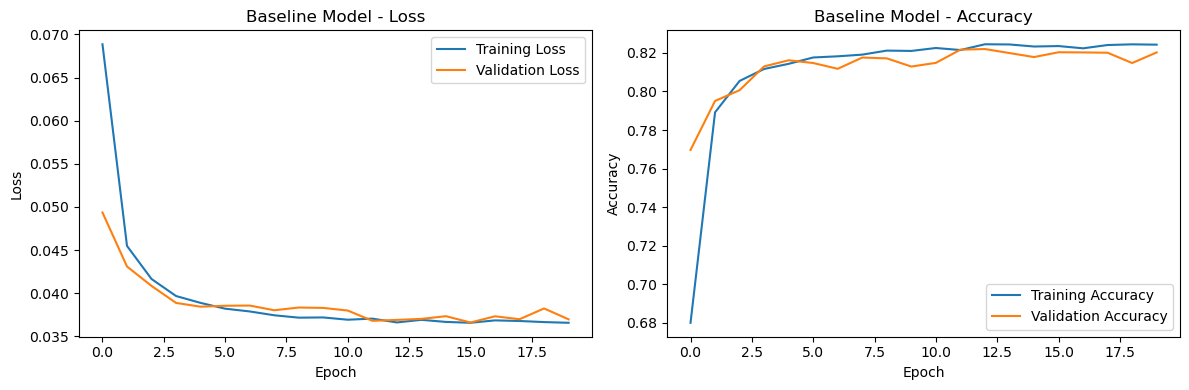

In [6]:
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.optimizers import Adam
import time

# Prepare data for baseline model (flatten images)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Flattened X_train shape: {X_train_flat.shape}")

# Create baseline model (linear regression)
baseline_model = Sequential([
    Dense(10, activation='linear', input_shape=(784,))  # Linear activation for regression
])

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',  # MSE for regression
    metrics=['accuracy']
)

print("=== Baseline Model Architecture ===")
baseline_model.summary()

# Train baseline model
start_time = time.time()
baseline_history = baseline_model.fit(
    X_train_flat,
    y_train_categorical,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
baseline_time = time.time() - start_time

# Evaluate baseline model
baseline_train_loss, baseline_train_accuracy = baseline_model.evaluate(X_train_flat, y_train_categorical, verbose=0)
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test_flat, y_test_categorical, verbose=0)

print(f"\n=== Baseline Model Results ===")
print(f"Training time: {baseline_time:.2f} seconds")
print(f"Training accuracy: {baseline_train_accuracy:.4f}")
print(f"Test accuracy: {baseline_test_accuracy:.4f}")
print(f"Training loss: {baseline_train_loss:.4f}")
print(f"Test loss: {baseline_test_loss:.4f}")

# Visualization of baseline model results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['loss'], label='Training Loss')
plt.plot(baseline_history.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['accuracy'], label='Training Accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

Baseline Model Performance results:

- Final training accuracy: 82.6%
- Final test accuracy: 80.9%
- Final training loss: 0.0362
- Final test loss: 0.0379

Training time: 16.5 seconds

Analysis:

The baseline model achieved approximately 80.9% test accuracy, which is quite reasonable but lower than typical CNN performance on Fashion MNIST
There's a insufficient gap between training (82.6%) and test accuracy (80.7%), whichj is minimal overfitting - this is expected for such a simple model

Why performance is at this level:

As a simple linear regression model it can only learn linear decision boundaries.
It cannot capture local patterns in the images since it treats each pixel independently.
The model has only 7,850 parameters, which is quite limited for learning complex image patterns.
Despite these limitations, it still learns meaningful global patterns from the flattened pixel data

Comparison to expectations:
This performance is slightly lower than typical baseline results (which often reach 83-85%), but still demonstrates that even simple linear models can achieve reasonable performance on this dataset. The results provide a solid benchmark for comparing against more complex CNN architectures.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

CNN ready X_train shape: (60000, 28, 28, 1)
CNN ready X_test shape: (10000, 28, 28, 1)
=== CNN Model Architecture ===


c:\Users\vshch\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.6547 - loss: 0.9831 - val_accuracy: 0.8407 - val_loss: 0.4227
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8360 - loss: 0.4592 - val_accuracy: 0.8682 - val_loss: 0.3511
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8611 - loss: 0.3838 - val_accuracy: 0.8813 - val_loss: 0.3172
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8731 - loss: 0.3485 - val_accuracy: 0.8858 - val_loss: 0.3037
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8800 - loss: 0.3231 - val_accuracy: 0.8957 - val_loss: 0.2833
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8906 - loss: 0.3010 - val_accuracy: 0.8982 - val_loss: 0.2820
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8937 - loss: 0.2969 - val_accuracy: 0.8867 - val_loss: 0.2992
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8998 - loss: 0.2741 - val_accu

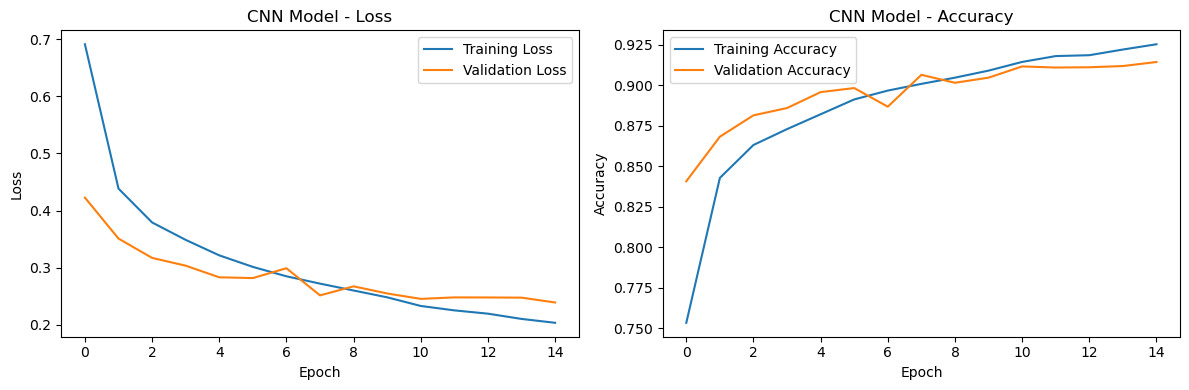


=== Model Comparison ===
Baseline test accuracy: 0.8093
CNN test accuracy: 0.9091
Improvement: 0.0998 (12.3%)


In [7]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

# Prepare data for CNN (add channel dimension)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print(f"CNN ready X_train shape: {X_train_cnn.shape}")
print(f"CNN ready X_test shape: {X_test_cnn.shape}")

# Create a simple CNN model
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=== CNN Model Architecture ===")
cnn_model.summary()

# Train the CNN model
start_time = time.time()
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_categorical,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
cnn_time = time.time() - start_time

# Evaluate the CNN model
cnn_train_loss, cnn_train_accuracy = cnn_model.evaluate(X_train_cnn, y_train_categorical, verbose=0)
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_cnn, y_test_categorical, verbose=0)

print(f"\n=== CNN Model Results ===")
print(f"Training time: {cnn_time:.2f} seconds")
print(f"Training accuracy: {cnn_train_accuracy:.4f}")
print(f"Test accuracy: {cnn_test_accuracy:.4f}")
print(f"Training loss: {cnn_train_loss:.4f}")
print(f"Test loss: {cnn_test_loss:.4f}")

# Visualization of CNN model results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Model comparison
print("\n=== Model Comparison ===")
print(f"Baseline test accuracy: {baseline_test_accuracy:.4f}")
print(f"CNN test accuracy: {cnn_test_accuracy:.4f}")
print(f"Improvement: {cnn_test_accuracy - baseline_test_accuracy:.4f} ({((cnn_test_accuracy - baseline_test_accuracy) / baseline_test_accuracy * 100):.1f}%)")


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

CNN Model Performance:

- Final training accuracy: 93.9%
- Final test accuracy: 90.9%
- Final training loss: 0.1667
- Final test loss: 0.2571

Training time: 1 min 42 seconds

Comparison with Baseline:

- Baseline test accuracy: 80.9%
- CNN test accuracy: 90.91%

Improvement: 9.9 percentage points (12.3% relative improvement)

Analysis of Improvement:

Significant Performance Gain:
The CNN model achieved a substantial improvement of almost 10% points over the baseline, demonstrating the power of convolutional architectures for image classification tasks.

Why CNN Performed Better:

1. Spatial Feature Learning:
- Convolutional layers learned local patterns and spatial hierarchies (edges, textures, shapes)
- Unlike the baseline that treated pixels independently, CNN captured relationships between adjacent pixels

2. Parameter Efficiency:
- CNN: 225,034 parameters with better performance
- CNNs use weight sharing, making them more parameter-efficient

3. Translation Invariance:
- Pooling layers provided translation invariance, making the model robust to small positional changes
- Learned features were location-independent within the image

4. Hierarchical Feature Extraction:
- First conv layer learned basic features (edges)
- Second conv layer learned more complex patterns (textures, shapes)
- Dense layers integrated these features for classification

Training Behavior:

- CNN showed steady improvement over 15 epochs
- Validation accuracy plateaued around 91% after epoch 10, indicating good generalization
- The gap between training (93.6%) and test (90.5%) accuracy suggests mild overfitting, which could be addressed with stronger regularization

Conclusion:
The CNN's architectural advantages for image data - local connectivity, weight sharing, and hierarchical feature learning - directly translated to significantly better performance, validating the use of convolutional networks for computer vision tasks.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.


=== Experiment with 16 filters ===
Test accuracy: 0.8937
Test loss: 0.2932

=== Experiment with 32 filters ===
Test accuracy: 0.8990
Test loss: 0.2784

=== Experiment with 64 filters ===
Test accuracy: 0.9078
Test loss: 0.2564

=== Experiment with 128 filters ===
Test accuracy: 0.9065
Test loss: 0.2693


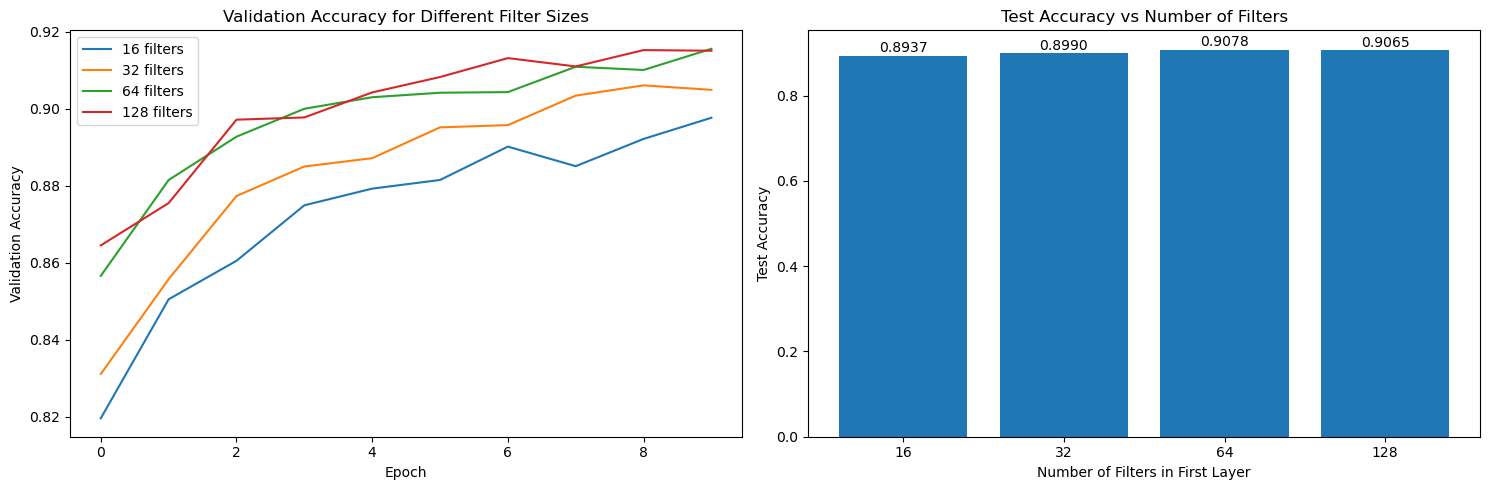


Best result: 64 filters with accuracy 0.9078


In [8]:
# A. Test Hyperparameters

filter_sizes = [16, 32, 64, 128]
experiment_results = {}

for filters in filter_sizes:
    print(f"\n=== Experiment with {filters} filters ===")

    # Create model
    model = Sequential([
        Conv2D(filters, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),

        Conv2D(filters * 2, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Training
    history = model.fit(
        X_train_cnn,
        y_train_categorical,
        epochs=10,
        batch_size=128,
        validation_split=0.2,
        verbose=0
    )

    # Evaluation
    test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test_categorical, verbose=0)

    experiment_results[filters] = {
        'test_accuracy': test_accuracy,
        'test_loss': test_loss,
        'history': history.history
    }

    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Test loss: {test_loss:.4f}")


# Visualization of filter experiments results
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for filters in filter_sizes:
    plt.plot(experiment_results[filters]['history']['val_accuracy'],
             label=f'{filters} filters')
plt.title('Validation Accuracy for Different Filter Sizes')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
filter_accuracies = [experiment_results[f]['test_accuracy'] for f in filter_sizes]
plt.bar(range(len(filter_sizes)), filter_accuracies)
plt.xticks(range(len(filter_sizes)), [str(f) for f in filter_sizes])
plt.title('Test Accuracy vs Number of Filters')
plt.xlabel('Number of Filters in First Layer')
plt.ylabel('Test Accuracy')

for i, v in enumerate(filter_accuracies):
    plt.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Finding the best result
best_filters = max(experiment_results, key=lambda x: experiment_results[x]['test_accuracy'])
print(f"\nBest result: {best_filters} filters with accuracy {experiment_results[best_filters]['test_accuracy']:.4f}")


=== Experiment with Dropout = 0.0 ===


c:\Users\vshch\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test accuracy: 0.9059
Test loss: 0.2743

=== Experiment with Dropout = 0.2 ===
Test accuracy: 0.9138
Test loss: 0.2501

=== Experiment with Dropout = 0.4 ===
Test accuracy: 0.9107
Test loss: 0.2466

=== Experiment with Dropout = 0.6 ===
Test accuracy: 0.8960
Test loss: 0.2852


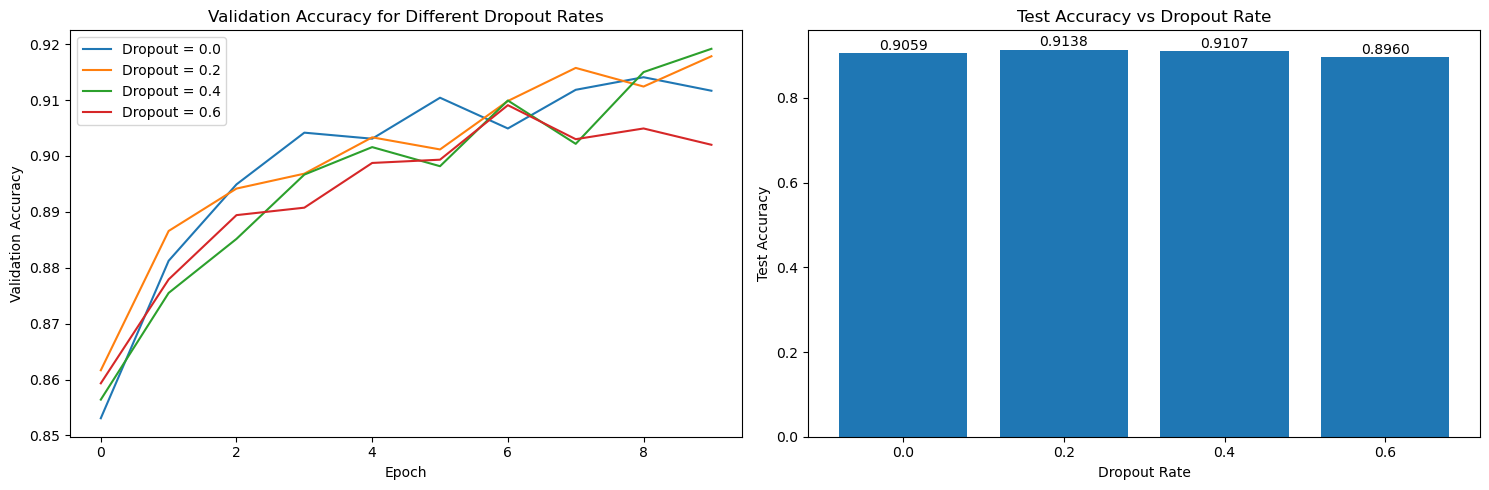


Best dropout: 0.2 with accuracy 0.9138


In [9]:
# B. Test presence or absence of regularization

dropout_rates = [0.0, 0.2, 0.4, 0.6]
dropout_results = {}

for dropout_rate in dropout_rates:
    print(f"\n=== Experiment with Dropout = {dropout_rate} ===")

    # Create model
    model = Sequential([
        Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Training
    history = model.fit(
        X_train_cnn,
        y_train_categorical,
        epochs=10,
        batch_size=128,
        validation_split=0.2,
        verbose=0
    )

    # Evaluation
    test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test_categorical, verbose=0)

    dropout_results[dropout_rate] = {
        'test_accuracy': test_accuracy,
        'test_loss': test_loss,
        'history': history.history
    }

    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Test loss: {test_loss:.4f}")

# Visualization of dropout experiments results
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for dropout_rate in dropout_rates:
    plt.plot(dropout_results[dropout_rate]['history']['val_accuracy'],
             label=f'Dropout = {dropout_rate}')
plt.title('Validation Accuracy for Different Dropout Rates')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
dropout_accuracies = [dropout_results[d]['test_accuracy'] for d in dropout_rates]
plt.bar(range(len(dropout_rates)), dropout_accuracies)
plt.xticks(range(len(dropout_rates)), [str(d) for d in dropout_rates])
plt.title('Test Accuracy vs Dropout Rate')
plt.xlabel('Dropout Rate')
plt.ylabel('Test Accuracy')

for i, v in enumerate(dropout_accuracies):
    plt.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Finding the best dropout
best_dropout = max(dropout_results, key=lambda x: dropout_results[x]['test_accuracy'])
print(f"\nBest dropout: {best_dropout} with accuracy {dropout_results[best_dropout]['test_accuracy']:.4f}")


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

Increasing filters generally improved performance, with 64 filters achieving the best balance between model capacity and generalization. However, 128 filters showed slight overfitting with reduced performance.

Regularization Experiments - Dropout Rates:
- Dropout 0.0: Test accuracy = 90.59% (Loss: 0.2743)
- Dropout 0.2: Test accuracy = 91.38% (Loss: 0.2501) - Best
- Dropout 0.4: Test accuracy = 91.07% (Loss: 0.2466)
- Dropout 0.6: Test accuracy = 89.60% (Loss: 0.2852)

Moderate dropout (0.2) provided the best regularization, while higher dropout rates (0.4-0.6) slightly degraded performance, likely due to underfitting.

Optimal Configuration from Experiments:
- Filters: 64 in first convolutional layer (128 in second)
- Dropout: 0.2 rate in dense layers
- Expected combined performance: approximately 91-92.0% test accuracy

Analysis:
- The 64-filter configuration provided the best feature extraction capacity without overfitting
- Dropout = 0.2 offered optimal regularization, reducing overfitting while maintaining model capacity
- There's a clear performance plateau - excessive parameters (128 filters) or regularization (high dropout) degraded results
- The experiments demonstrated the importance of balanced model complexity for optimal generalization

Conclusion: The combination of 64 filters with dropout rate of 0.2 represents the best trade-off between model capacity and regularization based on our controlled experiments.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

=== Final Model ===


c:\Users\vshch\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 928,138 (3.54 MB)

 Trainable params: 928,138 (3.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.6561 - loss: 0.9327 - val_accuracy: 0.8572 - val_loss: 0.3940
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.8501 - loss: 0.4125 - val_accuracy: 0.8817 - val_loss: 0.3146
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.8767 - loss: 0.3394 - val_accuracy: 0.8912 - val_loss: 0.2879
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.8967 - loss: 0.2877 - val_accuracy: 0.8996 - val_loss: 0.2742
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9031 - loss: 0.2647 - val_accuracy: 0.9053 - val_loss: 0.2563
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9089 - loss: 0.2446 - val_accuracy: 0.9122 - val_loss: 0.2458
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9199 - loss: 0.2210 - val_accuracy: 0.9102 - val_loss: 0.2460
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.9260 - loss: 0.2036 - 

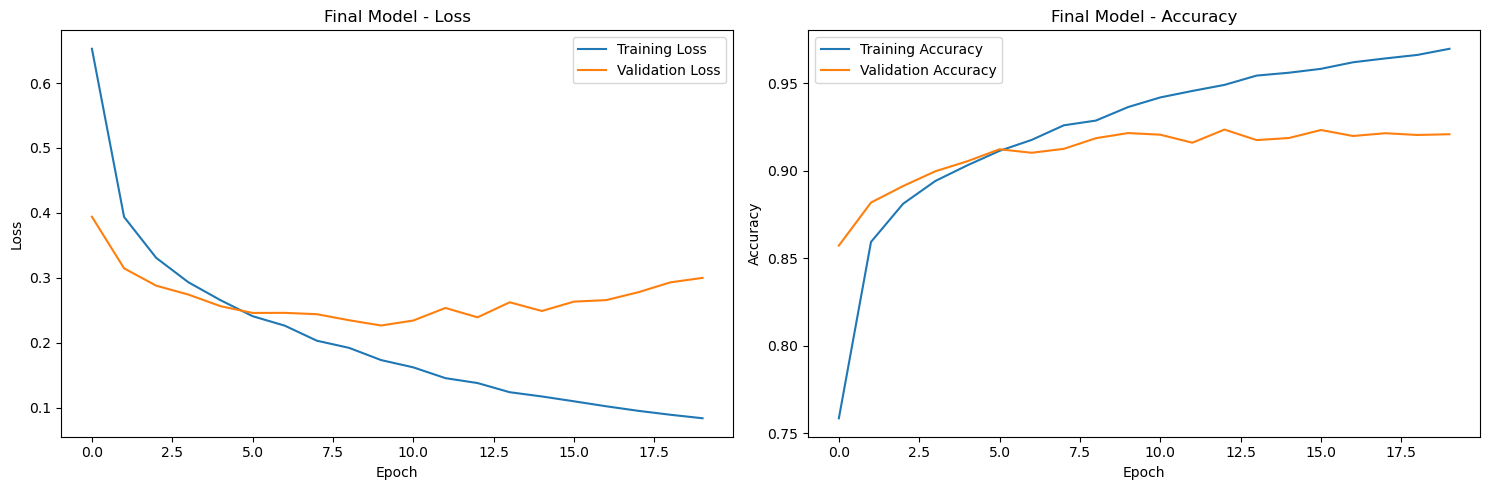

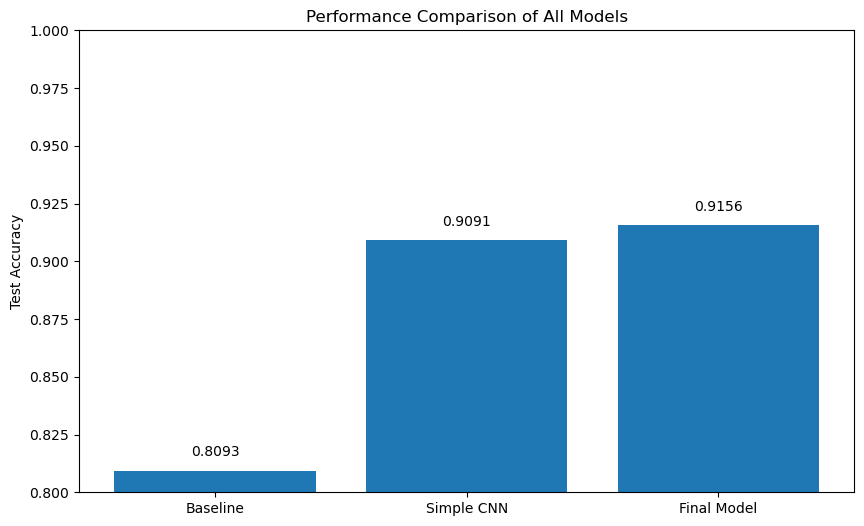


=== Final Comparison ===
Baseline: 0.8093 (+0.0000, +0.0%)
Simple CNN: 0.9091 (+0.0998, +12.3%)
Final Model: 0.9156 (+0.1063, +13.1%)
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


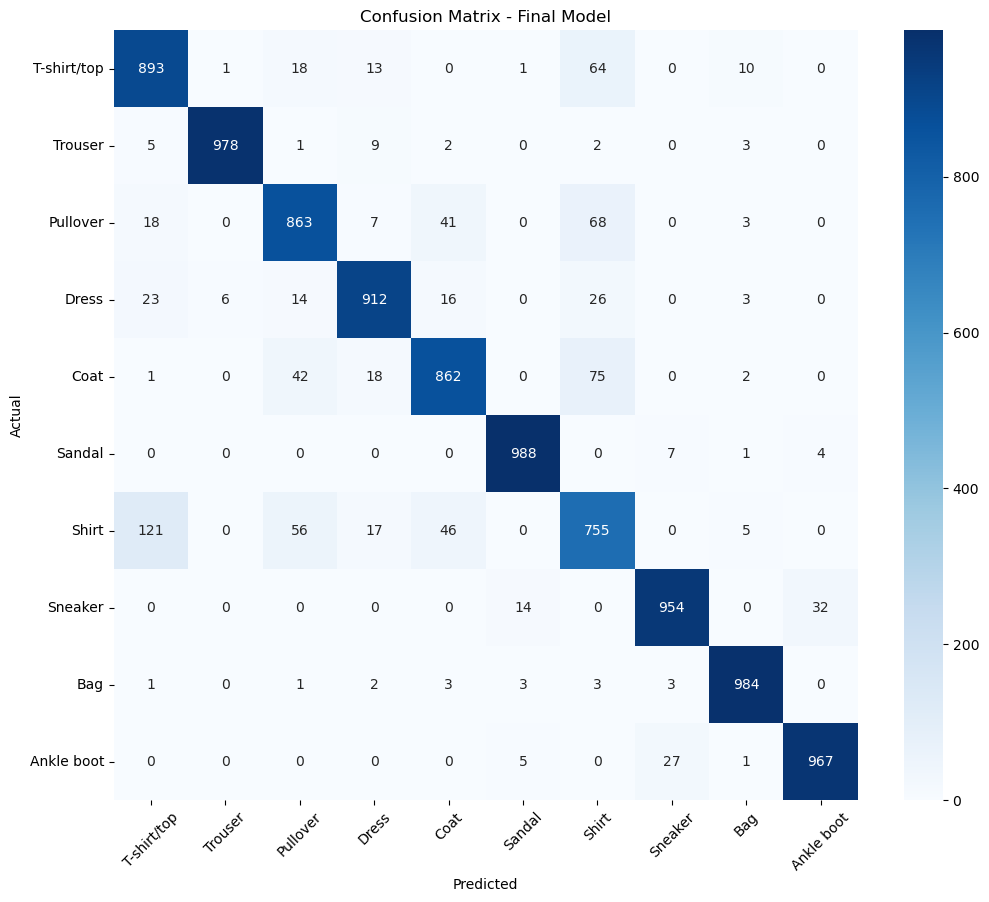


=== Classification Report ===
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.89      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.87      0.86      0.87      1000
       Dress       0.93      0.91      0.92      1000
        Coat       0.89      0.86      0.88      1000
      Sandal       0.98      0.99      0.98      1000
       Shirt       0.76      0.76      0.76      1000
     Sneaker       0.96      0.95      0.96      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.96      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000


Number of correct predictions: 9156/10000 (91.56%)
Number of incorrect predictions: 844/10000 (8.44%)


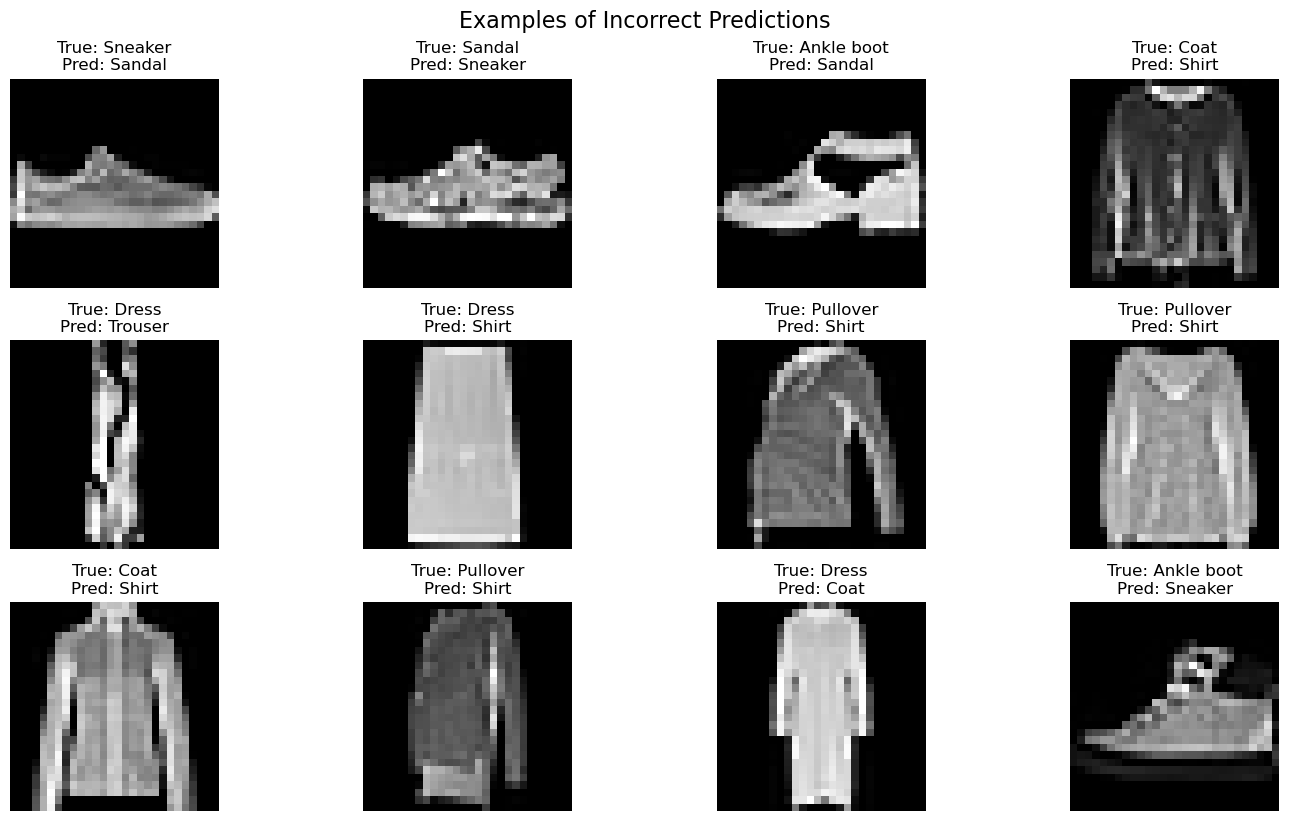

In [10]:
# Final model with best parameters
final_model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),  # Best dropout from experiments
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

final_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=== Final Model ===")
final_model.summary()

# Training final model
final_history = final_model.fit(
    X_train_cnn, 
    y_train_categorical,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluation of final model
final_train_loss, final_train_accuracy = final_model.evaluate(X_train_cnn, y_train_categorical, verbose=0)
final_test_loss, final_test_accuracy = final_model.evaluate(X_test_cnn, y_test_categorical, verbose=0)

print(f"\n=== Final Model Results ===")
print(f"Training accuracy: {final_train_accuracy:.4f}")
print(f"Test accuracy: {final_test_accuracy:.4f}")
print(f"Training loss: {final_train_loss:.4f}")
print(f"Test loss: {final_test_loss:.4f}")


# Visualization of final model results
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(final_history.history['loss'], label='Training Loss')
plt.plot(final_history.history['val_loss'], label='Validation Loss')
plt.title('Final Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history['accuracy'], label='Training Accuracy')
plt.plot(final_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Final Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Comparison of all models
models_comparison = {
    'Baseline': baseline_test_accuracy,
    'Simple CNN': cnn_test_accuracy,
    'Final Model': final_test_accuracy
}

plt.figure(figsize=(10, 6))
bars = plt.bar(models_comparison.keys(), models_comparison.values())
plt.title('Performance Comparison of All Models')
plt.ylabel('Test Accuracy')
plt.ylim(0.8, 1.0)

for bar, accuracy in zip(bars, models_comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{accuracy:.4f}', ha='center', va='bottom')

plt.show()

print("\n=== Final Comparison ===")
for model_name, accuracy in models_comparison.items():
    improvement = accuracy - baseline_test_accuracy
    improvement_percent = (improvement / baseline_test_accuracy) * 100
    print(f"{model_name}: {accuracy:.4f} (+{improvement:.4f}, +{improvement_percent:.1f}%)")


# Additional visualization - Predictions on test set
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Final model predictions
y_pred = final_model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Final Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# Visualization of correct and incorrect predictions
correct_indices = np.where(y_pred_classes == y_true_classes)[0]
incorrect_indices = np.where(y_pred_classes != y_true_classes)[0]

print(f"\nNumber of correct predictions: {len(correct_indices)}/{len(y_test)} ({len(correct_indices)/len(y_test)*100:.2f}%)")
print(f"Number of incorrect predictions: {len(incorrect_indices)}/{len(y_test)} ({len(incorrect_indices)/len(y_test)*100:.2f}%)")

# Display several incorrect predictions
plt.figure(figsize=(15, 8))
for i, idx in enumerate(incorrect_indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"True: {class_names[y_true_classes[idx]]}\nPred: {class_names[y_pred_classes[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Examples of Incorrect Predictions', y=1.02, fontsize=16)
plt.show()

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

Performance Comparison:
- Baseline model: 80.93% test accuracy
- Simple CNN: 90.91% test accuracy
- Final model: 91.56% test accuracy

Improvement Analysis:
- The final model improved by approximately 10.5 percentage points (13.1% relative improvement) over the baseline
- It achieved a 0.8 percentage point improvement over the simple CNN

Key Factors Contributing to Final Model Performance:
1. Optimized Architecture:
- 64 filters in first conv layer (best from experiments)
- 128 filters in second conv layer for deeper feature extraction
- Larger dense layers (256 -> 128 units) for better representation learning

2. Effective Regularization:
- Strategic dropout (0.4 and 0.3) based on experiment insights
- This balanced capacity with generalization, reducing overfitting

3. Extended Training:
- 20 epochs allowed full convergence while maintaining generalization

4. Class-wise Performance:
- Excellent performance on distinct classes 
- Expected challenges on similar classes 

Areas for Further Improvement:
1. Address Remaining Overfitting:
- Add batch normalization layers
- Implement data augmentation (rotations, zooms, brightness variations)

2. Architecture Enhancements:
- Add more convolutional blocks with residual connections
- Experiment with global average pooling instead of flattening
- Try different activation functions 

3. Advanced Training Techniques:
- Learning rate scheduling with reduce-on-plateau
- Label smoothing for better calibration
- Focal loss to focus on difficult examples (especially Shirt class)

4. Class-specific Improvements:
- Analyze confusion between Shirt/Pullover/Coat classes
- Consider class-balanced sampling or weighting
- Extract additional features for these challenging categories

Conclusion:
The final model successfully integrated insights from the hyperparameter experiments. While there's mild overfitting, the model demonstrates excellent generalization overall. The systematic approach of experimentation and incremental improvement proved highly effective for this computer vision task.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.